 # Setup

In [1]:
PASCODE_PATH = ".."

import sys
sys.path.append(PASCODE_PATH) # NOTE
import PASCode
PASCode.random_seed.set_seed(0)

import scanpy as sc
import numpy as np
import torch

DATA_PATH = '../data/' # NOTE

 # load data

In [2]:
file_path = DATA_PATH + 'synth_demo.h5ad'
adata = sc.read_h5ad(file_path)

 # load pre-trained model

In [3]:
model = PASCode.model.GAT(
    in_channels=adata.X.shape[1], out_channels=64, num_class=3, heads=4)
model.load_state_dict(torch.load('./trained_model.pt'))

<All keys matched successfully>

 # predict PAC scores

In [4]:
adata.obs['pac_score'] = model.predict(PASCode.Data().adata2gdata(adata))

/home/che82/athan/PASCode_github/tutorials/../PASCode/model.py:91: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:245.)
  edge_index = torch.LongTensor([coo_data.row, coo_data.col])


 # visualize

/home/che82/anaconda3/envs/PASCode/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/che82/anaconda3/envs/PASCode/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


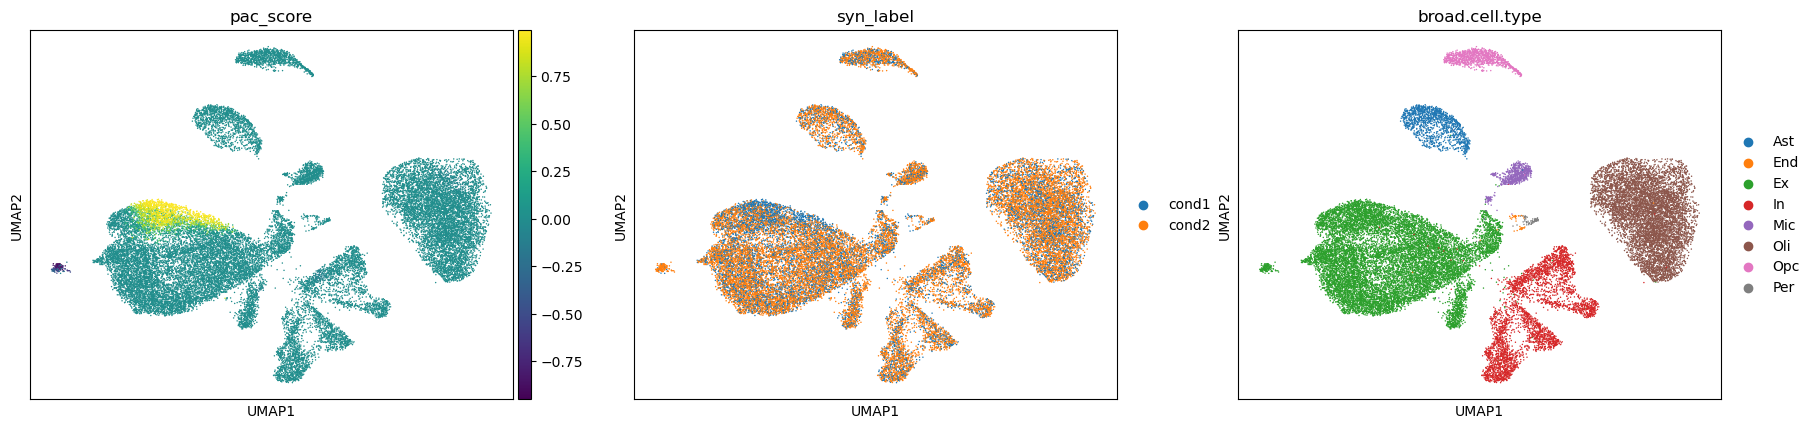

In [5]:
sc.pl.umap(adata, color=['pac_score', 'syn_label', 'broad.cell.type'])

# Using AD/NPS models trained on PsychAD for AD/NPS PAC scoring

In [ ]:
model = PASCode.model.GAT(
    in_channels=adata.X.shape[1], out_channels=64, num_class=3, heads=4)

# choose from c02_model, r01_model, c90_model, r91_model, c92_model
model.load_state_dict(torch.load('./pretrained_models/c02_model.pt'))

In [ ]:
# predict
adata = sc.read_h5ad(DATA_PATH + "seaad.h5ad")
adata.obs['pac_score'] = model.predict(PASCode.Data().adata2gdata(adata))

/home/che82/anaconda3/envs/PASCode/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


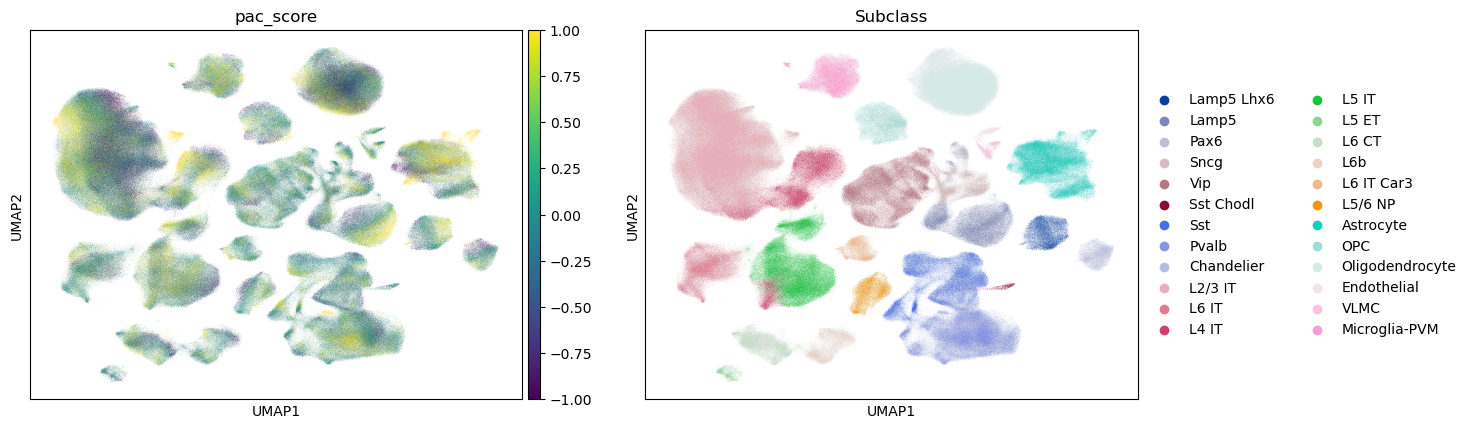

In [19]:
sc.pl.umap(adata, color=['pac_score', 'Subclass'])